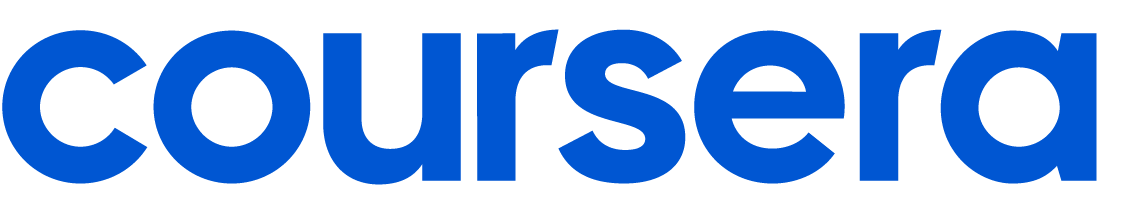

# Welcome to the Data Science Coding Challange!

Test your skills in a real-world coding challenge. Coding Challenges provide CS & DS Coding Competitions with Prizes and achievement badges!

CS & DS learners want to be challenged as a way to evaluate if they’re job ready. So, why not create fun challenges and give winners something truly valuable such as complimentary access to select Data Science courses, or the ability to receive an achievement badge on their Coursera Skills Profile - highlighting their performance to recruiters.

## Introduction

In this challenge, you'll get the opportunity to tackle one of the most industry-relevant machine learning problems with a unique dataset that will put your modeling skills to the test. Financial loan services are leveraged by companies across many industries, from big banks to financial institutions to government loans. One of the primary objectives of companies with financial loan services is to decrease payment defaults and ensure that individuals are paying back their loans as expected. In order to do this efficiently and systematically, many companies employ machine learning to predict which individuals are at the highest risk of defaulting on their loans, so that proper interventions can be effectively deployed to the right audience.

In this challenge, we will be tackling the loan default prediction problem on a very unique and interesting group of individuals who have taken financial loans. 

Imagine that you are a new data scientist at a major financial institution and you are tasked with building a model that can predict which individuals will default on their loan payments. We have provided a dataset that is a sample of individuals who received loans in 2021. 

This financial institution has a vested interest in understanding the likelihood of each individual to default on their loan payments so that resources can be allocated appropriately to support these borrowers. In this challenge, you will use your machine learning toolkit to do just that!

## Understanding the Datasets

### Train vs. Test
In this competition, you’ll gain access to two datasets that are samples of past borrowers of a financial institution that contain information about the individual and the specific loan. One dataset is titled `train.csv` and the other is titled `test.csv`.

`train.csv` contains 70% of the overall sample (255,347 borrowers to be exact) and importantly, will reveal whether or not the borrower has defaulted on their loan payments (the “ground truth”).

The `test.csv` dataset contains the exact same information about the remaining segment of the overall sample (109,435 borrowers to be exact), but does not disclose the “ground truth” for each borrower. It’s your job to predict this outcome!

Using the patterns you find in the `train.csv` data, predict whether the borrowers in `test.csv` will default on their loan payments, or not.

### Dataset descriptions
Both `train.csv` and `test.csv` contain one row for each unique Loan. For each Loan, a single observation (`LoanID`) is included during which the loan was active. 

In addition to this identifier column, the `train.csv` dataset also contains the target label for the task, a binary column `Default` which indicates if a borrower has defaulted on payments.

Besides that column, both datasets have an identical set of features that can be used to train your model to make predictions. Below you can see descriptions of each feature. Familiarize yourself with them so that you can harness them most effectively for this machine learning task!

## How to Submit your Predictions to Coursera
Submission Format:

In this notebook you should follow the steps below to explore the data, train a model using the data in `train.csv`, and then score your model using the data in `test.csv`. Your final submission should be a dataframe (call it `prediction_df` with two columns and exactly 109,435 rows (plus a header row). The first column should be `LoanID` so that we know which prediction belongs to which observation. The second column should be called `predicted_probability` and should be a numeric column representing the __likelihood that the borrower will default__.

Your submission will show an error if you have extra columns (beyond `LoanID` and `predicted_probability`) or extra rows. The order of the rows does not matter.

The naming convention of the dataframe and columns are critical for our autograding, so please make sure to use the exact naming conventions of `prediction_df` with column names `LoanID` and `predicted_probability`!

To determine your final score, we will compare your `predicted_probability` predictions to the source of truth labels for the observations in `test.csv` and calculate the [ROC AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html). We choose this metric because we not only want to be able to predict which loans will default, but also want a well-calibrated likelihood score that can be used to target interventions and support most accurately.

## Import Python Modules

First, import the primary modules that will be used in this project. Remember as this is an open-ended project please feel free to make use of any of your favorite libraries that you feel may be useful for this challenge. For example some of the following popular packages may be useful:

- pandas
- numpy
- Scipy
- Scikit-learn
- keras
- maplotlib
- seaborn
- etc, etc

## Objective

The goal of this project is to predict the probability that a borrower will default on a loan.

This is a binary classification problem where:
- 1 = Default
- 0 = No Default

The model is evaluated using ROC AUC score, which measures how well the model separates risky borrowers from non-risky borrowers.

In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

In [38]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (255347, 18)
Test shape: (109435, 17)


## Dataset Overview

We inspect structure, target distribution, and feature types to understand data quality and imbalance.

In [39]:
y = train["Default"]
print(y.value_counts(normalize=True))

0    0.883872
1    0.116128
Name: Default, dtype: float64


In [40]:
X = train.drop(columns=["Default", "LoanID"])
test_id = test["LoanID"]
test = test.drop(columns=["LoanID"])

## Feature Engineering

We create financial risk indicators to improve model learning:
- Debt burden
- Income buffer
- Risk index
- Stability score
- Non-linear transformations

In [41]:
def features(df):
    df = df.copy()

    df["Debt_Burden"] = df["LoanAmount"] / (df["Income"] + 1)
    df["Income_Buffer"] = df["Income"] - df["LoanAmount"]

    df["Risk_Index"] = df["DTIRatio"] * 0.5 + (df["InterestRate"] / 100) * 0.5

    df["Credit_Risk_Score"] = df["CreditScore"] / (df["DTIRatio"] + 1)

    df["Stability_Score"] = df["MonthsEmployed"] / (df["Age"] + 1)

    df["Log_Income"] = np.log1p(df["Income"])
    df["Log_Loan"] = np.log1p(df["LoanAmount"])

    df["Stress"] = df["LoanAmount"] * df["DTIRatio"]

    return df

X = features(X)
test = features(test)

In [42]:
cat_cols = X.select_dtypes(include="object").columns

for col in cat_cols:
    risk_map = train.groupby(col)["Default"].mean()
    X[col] = X[col].map(risk_map)
    test[col] = test[col].map(risk_map)

global_mean = y.mean()

X = X.fillna(global_mean)
test = test.fillna(global_mean)

## Model Selection

We use ExtraTreesClassifier due to:
- Strong performance on tabular data
- Robustness to noise
- Minimal preprocessing requirements

In [43]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [44]:
model = ExtraTreesClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model trained ✔")

Model trained ✔


In [45]:
val_pred = model.predict_proba(X_val)[:, 1]

auc = roc_auc_score(y_val, val_pred)

print("ROC AUC:", auc)

ROC AUC: 0.7517574454230175


            Feature  Importance
0               Age    0.083641
6      InterestRate    0.065722
16      Debt_Burden    0.055074
4    MonthsEmployed    0.052126
21       Log_Income    0.047160
1            Income    0.045284
17    Income_Buffer    0.044766
20  Stability_Score    0.042716
9         Education    0.040775
7          LoanTerm    0.040641


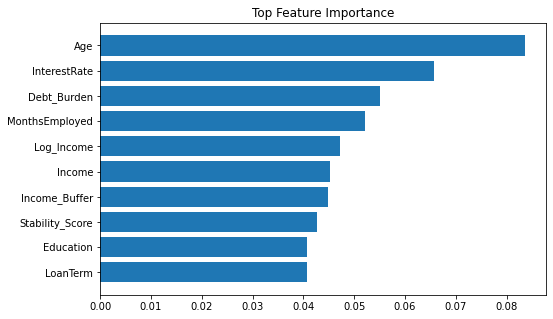

In [46]:
importances = model.feature_importances_
features_names = X.columns

feat_df = pd.DataFrame({
    "Feature": features_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_df.head(10))

plt.figure(figsize=(8,5))
plt.barh(feat_df["Feature"][:10][::-1], feat_df["Importance"][:10][::-1])
plt.title("Top Feature Importance")
plt.show()

In [47]:
model.fit(X, y);

In [48]:
test_pred = model.predict_proba(test)[:, 1]

In [49]:
print(pd.Series(test_pred).describe())

count    109435.000000
mean          0.119914
std           0.090879
min           0.003515
25%           0.056538
50%           0.094105
75%           0.156150
max           0.786073
dtype: float64


In [50]:
prediction_df = pd.DataFrame({
    "LoanID": test_id,
    "predicted_probability": test_pred
})

prediction_df.to_csv("submission.csv", index=False)

prediction_df.head()

,LoanID,predicted_probability
0,7RYZGMKJIR,0.077844
1,JDL5RH07AM,0.048311
2,STAL716Y79,0.046678
3,SO0KKJ3IQB,0.181776
4,T99CWTYDCP,0.120632


## Conclusion

This project demonstrates a full end-to-end machine learning pipeline for credit risk prediction including:

- Data preprocessing
- Feature engineering
- Risk-based encoding
- Ensemble modeling
- Model evaluation using ROC AUC

The final model achieves a stable predictive performance suitable for baseline credit scoring systems.

Future improvements could include:
- External credit bureau data
- Temporal repayment behavior
- Advanced gradient boosting models